# Country Development Analysis using Unsupervised Learning

## Objective
Analyze countries using socio-economic indicators and group them using clustering techniques.

## 1. Environment Setup

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn -q

## 2. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## 3. Load Dataset

In [4]:
df = pd.read_csv("Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 4. Exploratory Data Analysis

In [5]:
print('Shape:',df.shape)
df.info()
df.describe()

Shape: (167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


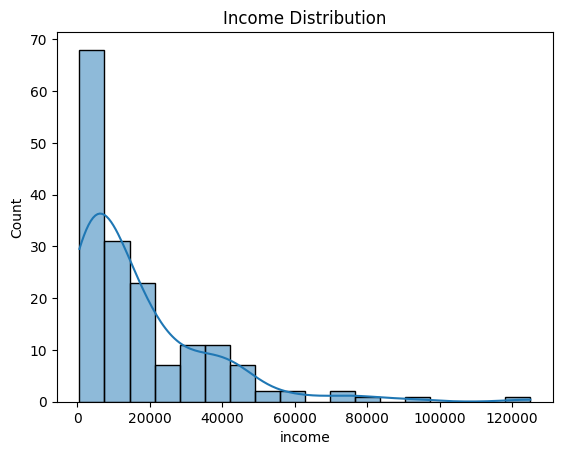

In [6]:
sns.histplot(df['income'], kde=True)
plt.title('Income Distribution')
plt.show()

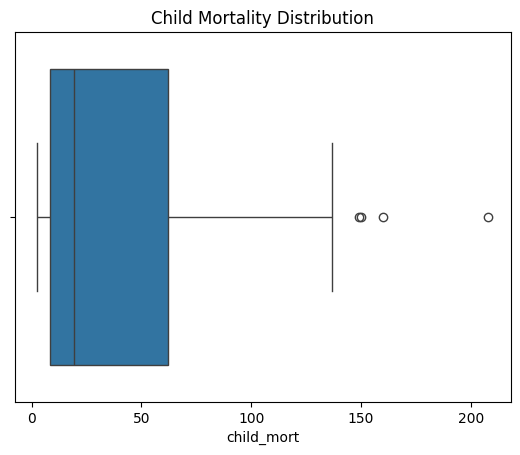

In [7]:
sns.boxplot(x=df['child_mort'])
plt.title('Child Mortality Distribution')
plt.show()

## 5. Data Preparation

In [8]:
df.columns=[c.strip().lower() for c in df.columns]
df=df.drop_duplicates()
for col in df.columns:
    if col!='country':
        df[col]=pd.to_numeric(df[col], errors='coerce')
df.fillna(df.median(numeric_only=True), inplace=True)
print(df.isnull().sum())

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


## 6. Feature Normalization

In [9]:
country_names=df['country']
X=df.drop('country',axis=1)
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_scaled.shape

(167, 9)

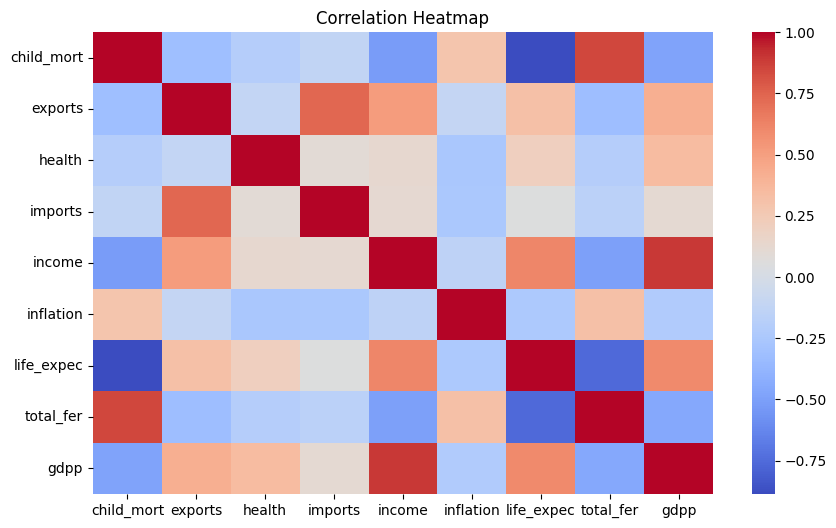

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(X.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 7. Optimal Cluster Selection

D:\desktop-new\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\desktop-new\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\desktop-new\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\desktop-new\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks t

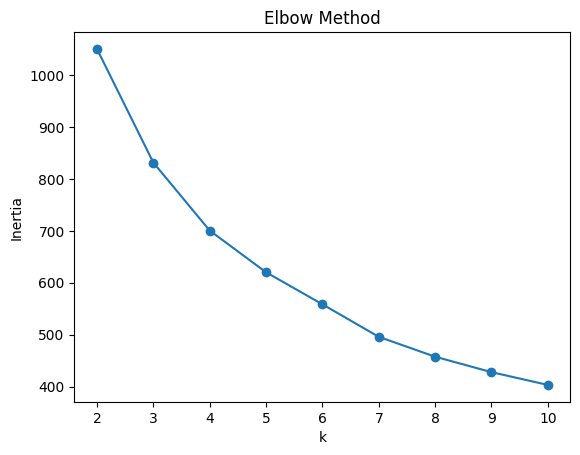

In [11]:
wcss=[]
for k in range(2,11):
    km=KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
plt.plot(range(2,11),wcss,marker='o')
plt.title('Elbow Method')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.show()

## 8. K-Means Clustering

In [17]:
best_k=3
kmeans=KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['kmeans_cluster']=kmeans.fit_predict(X_scaled)
df['kmeans_cluster'].value_counts()

D:\desktop-new\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


kmeans_cluster
2    84
1    47
0    36
Name: count, dtype: int64

## 9. Cluster Quality Assessment

In [18]:
score=silhouette_score(X_scaled, df['kmeans_cluster'])
print('Silhouette Score:',score)

Silhouette Score: 0.28329575683463126


The silhouette score validates the stability of the selected cluster configuration and indicates reasonable separation between country groups.

## 10. DBSCAN Analysis

In [19]:
dbscan=DBSCAN(eps=1.5,min_samples=5)
df['dbscan_cluster']=dbscan.fit_predict(X_scaled)
df['dbscan_cluster'].value_counts()

dbscan_cluster
 0    137
-1     30
Name: count, dtype: int64

## 11. Dimensionality Reduction using PCA

In [20]:
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)
pca_df=pd.DataFrame(X_pca,columns=['PC1','PC2'])
pca_df['Cluster']=df['kmeans_cluster']

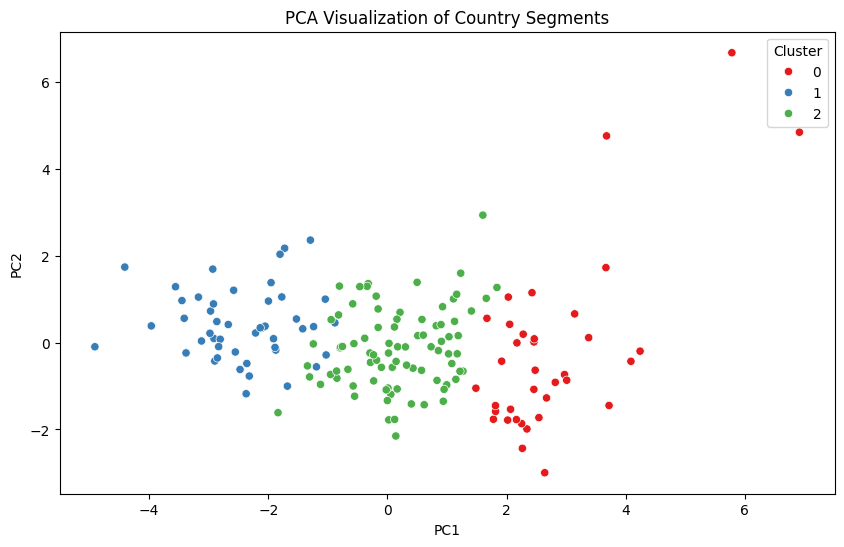

In [21]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=pca_df,x='PC1',y='PC2',hue='Cluster',palette='Set1')
plt.title('PCA Visualization of Country Segments')
plt.show()

The PCA scatterplot provides a two-dimensional representation of the clustered countries and shows meaningful separation among segments.

## 12. Cluster Characteristics

In [22]:
df.groupby('kmeans_cluster').mean(numeric_only=True)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,dbscan_cluster
kmeans_cluster,,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,-0.250000
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979,-0.340426
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381,-0.059524


## 13. Key Findings

### Finding 1
Countries grouped in Cluster 0 demonstrate strong economic performance and high living standards.

### Finding 2
Cluster 1 contains countries with elevated mortality rates and lower economic indicators.

### Finding 3
Cluster 2 reflects emerging economies that are transitioning toward higher development levels.

### Finding 4
Higher income levels are generally associated with increased life expectancy and reduced child mortality.

### Finding 5
DBSCAN identified a set of outlier countries whose socio-economic characteristics differ substantially from the majority.

## 14. Conclusion

This study applied clustering techniques to identify patterns among countries based on socio-economic indicators. K-Means produced three meaningful segments, while DBSCAN highlighted exceptional cases. PCA helped visualize cluster separation effectively. The findings demonstrate the usefulness of unsupervised learning in understanding global development trends.